In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/jainpakshal/Sales-Prediction-using-Python/refs/heads/main/Advertising.csv"

df = pd.read_csv(url)

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (200, 5)

Columns:
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
correlation = df.corr()

print(correlation)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


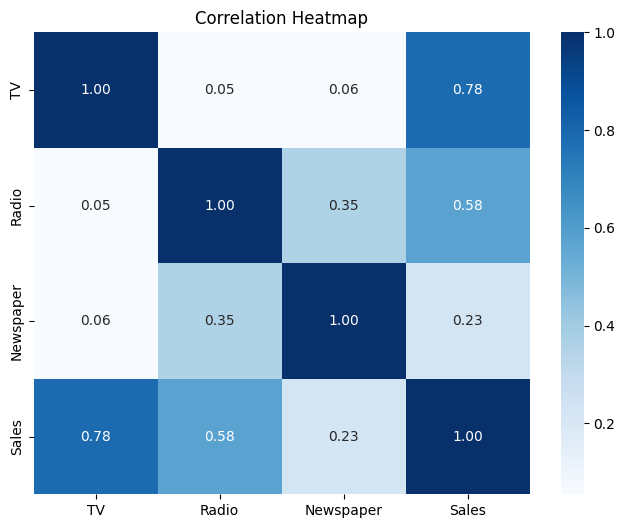

In [8]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
# Features

X = df[["TV", "Radio", "Newspaper"]]

# Target

y = df["Sales"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (160, 3)
Testing Data : (40, 3)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [13]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Calculate metrics

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print results

print("R² Score :", round(r2, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))

R² Score : 0.8994
Mean Absolute Error (MAE): 1.4608
Mean Squared Error (MSE): 3.1741
Root Mean Squared Error (RMSE): 1.7816


In [14]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


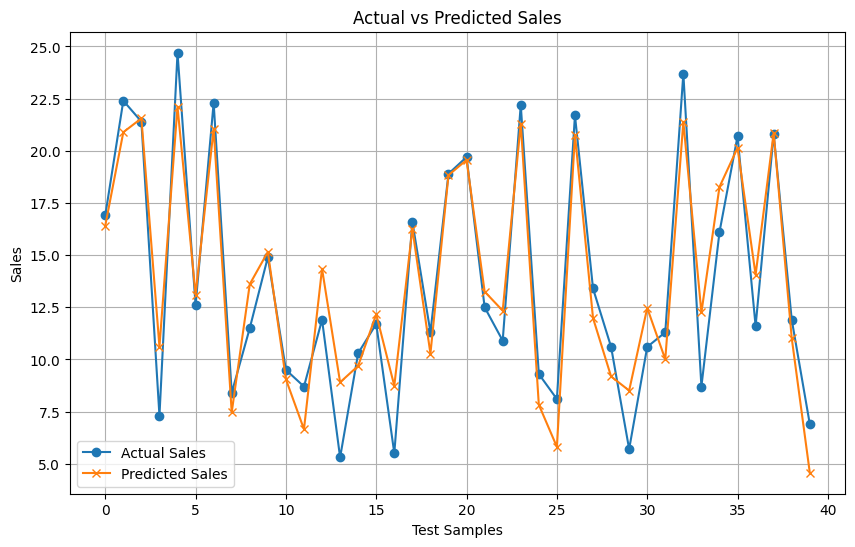

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    y_test.values,
    label="Actual Sales",
    marker='o'
)

plt.plot(
    y_pred,
    label="Predicted Sales",
    marker='x'
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Test Samples")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
coefficients = pd.DataFrame({
    "Advertising Platform": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Advertising Platform,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


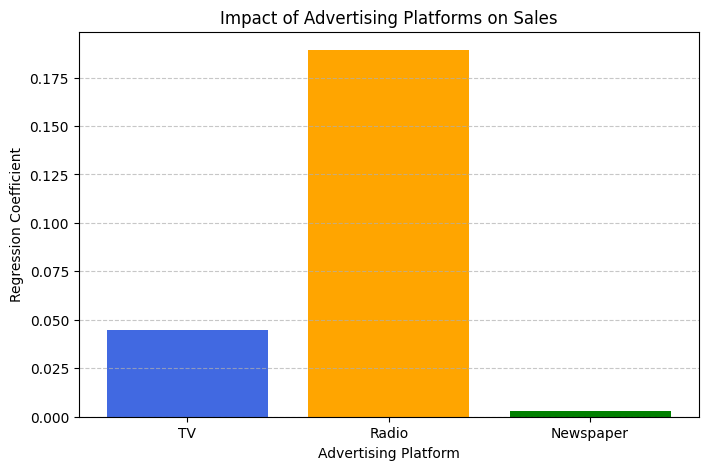

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    coefficients["Advertising Platform"],
    coefficients["Coefficient"],
    color=["royalblue", "orange", "green"]
)

plt.title("Impact of Advertising Platforms on Sales")
plt.xlabel("Advertising Platform")
plt.ylabel("Regression Coefficient")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [18]:
### Observation

#The regression coefficients indicate the influence of different advertising platforms on sales. Among the three advertising channels, **TV and Radio advertising have the strongest positive impact on sales**, while **Newspaper advertising contributes relatively less**. This suggests that increasing investment in TV and Radio campaigns is more likely to improve sales performance.